# Tentang Dataset

Dataset ini merupakan dataset sintetis yang berisi data antropometri anak dengan fokus pada indikator stunting dan wasting. Dataset yang digunakan pada notebook ini berasal langsung dari Kaggle, yaitu **Stunting Wasting Dataset (Synthetic)**.

Dataset ini digunakan untuk menganalisis pola pertumbuhan dan status gizi balita berdasarkan data antropometri. Karena dataset berasal dari sumber publik dan relatif sudah terstruktur, proses data cleaning pada notebook ini difokuskan pada validasi kualitas data, pengecekan missing value, duplikasi, konsistensi kategori, tipe data, serta kelayakan nilai antropometri sebelum dataset digunakan untuk pemodelan Machine Learning.

## Fitur

Dataset ini menyediakan beberapa fitur utama, yaitu:

- Jenis Kelamin
- Umur dalam bulan
- Berat badan dalam kilogram
- Tinggi badan dalam centimeter

## Label

Dataset ini memiliki dua label target, yaitu:

- Status stunting
- Status wasting

## Tujuan Penggunaan

Dataset ini digunakan untuk:

- Menganalisis pola pertumbuhan dan status gizi balita
- Melakukan proses data wrangling pada data tabular antropometri
- Menyiapkan data untuk model prediksi stunting dan wasting

## Sumber Dataset

Dataset berasal dari Kaggle:

[Kaggle - Stunting Wasting Dataset (Synthetic)](https://www.kaggle.com/datasets/jabirmuktabir/stunting-wasting-dataset/data)


### **Data Dictionary**

| Nama Kolom | Tipe Data | Deskripsi | Rentang Nilai / Kategori |
| :--- | :--- | :--- | :--- |
| **Jenis Kelamin** | Kategori | Jenis kelamin balita | Laki-laki, Perempuan |
| **Umur (bulan)** | Numerik | Usia balita dalam satuan bulan | 0 - 60 (bulan) |
| **Tinggi Badan (cm)** | Numerik | Tinggi badan balita dalam satuan sentimeter | 40 - 120 (cm) |
| **Berat Badan (kg)** | Numerik | Berat badan balita dalam satuan kilogram | 1.0 - 30.0 (kg) |
| **Wasting** | Kategori | Status gizi berdasarkan berat badan vs tinggi | Normal weight, Underweight, Severely Underweight, Risk of Overweight |
| **Stunting** | Kategori | Label target: Status gizi berdasarkan tinggi vs umur | Normal, Stunted, Severely Stunted, Tall |

---

# Menentukan Pertanyaan Bisnis   

1.  Bagaimana pola hubungan umur, tinggi badan, dan berat badan terhadap status stunting dan wasting pada balita?
2. Apakah distribusi tinggi dan berat badan balita stunting berbeda signifikan dibandingkan balita non-stunting?
3. Pada rentang usia berapa perbedaan kondisi fisik antara balita stunting dan non-stunting mulai terlihat jelas?

---

# Tahap Pengerjaan (Workflow)

## 1. Data Wrangling ✅
Tahap awal untuk mengumpulkan, memahami, dan menyiapkan dataset sebelum dilakukan analisis lebih lanjut.

Proses yang dilakukan meliputi:
- Data gathering (pengumpulan data)
- Assessing data (pemeriksaan kualitas data)
- Memahami struktur dan tipe data
- Identifikasi permasalahan pada dataset

---

## 2. Data Cleaning ✅
Tahap pembersihan data untuk memperbaiki permasalahan yang ditemukan pada proses sebelumnya agar data lebih konsisten dan siap digunakan.

Proses yang dilakukan meliputi:
- Menangani missing values
- Menghapus data duplikat
- Memperbaiki inkonsistensi data
- Membersihkan format data
- Menangani outlier jika diperlukan

---

## 3. Exploratory Data Analysis (EDA) ✅
Tahap eksplorasi data untuk memahami karakteristik dataset serta menemukan pola dan hubungan antar variabel.

Analisis yang dilakukan meliputi:
- Distribusi data
- Perbandingan antar kategori
- Analisis hubungan antar fitur
- Visualisasi data
- Penarikan insight awal

---

## 4. Data Preprocessing ✅
Tahap persiapan data sebelum digunakan dalam proses machine learning.

Proses yang dilakukan meliputi:
- Encoding data kategorikal
- Feature engineering
- Feature selection
- Data scaling
- Splitting data train dan test


---

# Data Wrangling

## 1. Gathering Data

### Import Semua Packages/Library yang Digunakan

In [49]:
import os

# Import library dasar
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Nonaktifkan warning agar notebook lebih bersih
import warnings
warnings.filterwarnings('ignore')

### Membaca Dataset dari Kaggle


In [50]:
# Dataset utama: dataset awal dari Kaggle.
# Jika file CSV Kaggle sudah tersedia di folder notebook, file lokal akan digunakan.
# Jika belum tersedia, notebook akan mencoba mengunduh dataset publik dari Kaggle menggunakan kagglehub.

from pathlib import Path
import sys
import subprocess

DATASET_SLUG = 'jabirmuktabir/stunting-wasting-dataset'

local_candidates = [
    Path('stunting_wasting_dataset.csv'),
    Path('Stunting_Wasting_Dataset.csv'),
    Path('stunting_wasting_dataset_synthetic.csv'),
]

DATASET_FILE = next((path for path in local_candidates if path.exists()), None)

if DATASET_FILE is None:
    try:
        import kagglehub
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])
        import kagglehub

    dataset_dir = Path(kagglehub.dataset_download(DATASET_SLUG))
    csv_files = sorted(dataset_dir.rglob('*.csv'))

    if not csv_files:
        raise FileNotFoundError('File CSV tidak ditemukan setelah mengunduh dataset Kaggle.')

    DATASET_FILE = csv_files[0]

print('Dataset yang digunakan:', DATASET_FILE)
print('Sumber dataset: Kaggle - Stunting Wasting Dataset (Synthetic)')


Using Colab cache for faster access to the 'stunting-wasting-dataset' dataset.
Dataset yang digunakan: /kaggle/input/stunting-wasting-dataset/stunting_wasting_dataset.csv
Sumber dataset: Kaggle - Stunting Wasting Dataset (Synthetic)


In [51]:
# Mengecek file dataset yang digunakan
full_path = DATASET_FILE
print('Alamat file CSV:', full_path)


Alamat file CSV: /kaggle/input/stunting-wasting-dataset/stunting_wasting_dataset.csv


In [52]:
# Membaca dataset awal dari Kaggle
# Dataset dibaca apa adanya, lalu divalidasi melalui tahap assessing dan data cleaning.

df = pd.read_csv(full_path)
print('Ukuran dataset awal:', df.shape)


Ukuran dataset awal: (100000, 6)


### Melihat 5 Data Pertama


In [53]:
df.head()

,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight
1,Laki-laki,20,77.7,8.5,Stunted,Underweight
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight


### Melihat 5 Data Terakhir

In [54]:
df.tail()

,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
99995,Laki-laki,11,75.3,7.3,Normal,Underweight
99996,Laki-laki,21,93.7,14.8,Normal,Risk of Overweight
99997,Perempuan,18,82.9,12.6,Normal,Risk of Overweight
99998,Laki-laki,7,73.6,5.5,Normal,Severely Underweight
99999,Laki-laki,17,88.8,6.7,Normal,Severely Underweight


---

## 2. Data Understanding

### Melihat Jumlah Baris dan Kolom

In [55]:
df.shape

(100000, 6)

### Melihat Informasi Dataset

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Jenis Kelamin      100000 non-null  object 
 1   Umur (bulan)       100000 non-null  int64  
 2   Tinggi Badan (cm)  100000 non-null  float64
 3   Berat Badan (kg)   100000 non-null  float64
 4   Stunting           100000 non-null  object 
 5   Wasting            100000 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 4.6+ MB


### Melihat Statistik Deskriptif

In [57]:
df.describe()

,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg)
count,100000.000000,100000.000000,100000.000000
mean,11.992580,73.132657,9.259256
std,7.199671,11.360846,3.300780
min,0.000000,42.600000,1.000000
25%,6.000000,65.500000,6.900000
50%,12.000000,74.200000,9.200000
75%,18.000000,81.400000,11.700000
max,24.000000,97.600000,17.200000


### Melihat Nama Kolom

In [58]:
df.columns

Index(['Jenis Kelamin', 'Umur (bulan)', 'Tinggi Badan (cm)',
       'Berat Badan (kg)', 'Stunting', 'Wasting'],
      dtype='object')

---

## 3. Assessing Data

### Mengecek Missing Value

In [59]:
print("\nJumlah missing values:")
print(df.isnull().sum())


Jumlah missing values:
Jenis Kelamin        0
Umur (bulan)         0
Tinggi Badan (cm)    0
Berat Badan (kg)     0
Stunting             0
Wasting              0
dtype: int64


### Mengecek Data Duplikat

In [60]:
print(f"Jumlah duplikasi: {df.duplicated().sum()}")

Jumlah duplikasi: 7308


### Mengecek Tipe Data

In [61]:
df.dtypes

,0
Jenis Kelamin,object
Umur (bulan),int64
Tinggi Badan (cm),float64
Berat Badan (kg),float64
Stunting,object
Wasting,object


### Mengecek Kualitas Data

In [62]:
# Memeriksa nilai minimum pada fitur numerik
kolom_numerik_awal = ['Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)']

print('Nilai Minimum:')
for kolom in kolom_numerik_awal:
    nilai_numeric = pd.to_numeric(df[kolom], errors='coerce')
    print(f'{kolom}: {nilai_numeric.min()}')

# Nilai tidak valid dicatat terlebih dahulu, lalu ditangani pada tahap Data Cleaning jika ditemukan.
for kolom in kolom_numerik_awal:
    nilai_numeric = pd.to_numeric(df[kolom], errors='coerce')
    jumlah_negatif = (nilai_numeric < 0).sum()
    jumlah_non_numeric = nilai_numeric.isna().sum() - df[kolom].isna().sum()
    print(f'Jumlah nilai negatif pada {kolom}: {jumlah_negatif}')
    print(f'Jumlah nilai non-numerik pada {kolom}: {jumlah_non_numeric}')


Nilai Minimum:
Umur (bulan): 0
Tinggi Badan (cm): 42.6
Berat Badan (kg): 1.0
Jumlah nilai negatif pada Umur (bulan): 0
Jumlah nilai non-numerik pada Umur (bulan): 0
Jumlah nilai negatif pada Tinggi Badan (cm): 0
Jumlah nilai non-numerik pada Tinggi Badan (cm): 0
Jumlah nilai negatif pada Berat Badan (kg): 0
Jumlah nilai non-numerik pada Berat Badan (kg): 0


In [63]:
# Mengecek nilai maksimum pada fitur fisik
kolom_numerik_awal = ['Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)']

print('Nilai Maksimum:')
for kolom in kolom_numerik_awal:
    nilai_numeric = pd.to_numeric(df[kolom], errors='coerce')
    print(f'{kolom}: {nilai_numeric.max()}')

umur_numeric = pd.to_numeric(df['Umur (bulan)'], errors='coerce')
print('Jumlah data usia > 60 bulan:', (umur_numeric > 60).sum())


Nilai Maksimum:
Umur (bulan): 24
Tinggi Badan (cm): 97.6
Berat Badan (kg): 17.2
Jumlah data usia > 60 bulan: 0


In [64]:
# Menampilkan kategori unik pada fitur kategorikal
print('Kategori Jenis Kelamin:')
print(df['Jenis Kelamin'].unique())

print('\nKategori Stunting:')
print(df['Stunting'].unique())

print('\nKategori Wasting:')
print(df['Wasting'].unique())

# Validasi kategori dilakukan dengan menghitung jumlah nilai tidak valid.
# Baris tidak valid akan difilter pada tahap Data Cleaning.
valid_jk = {'Laki-laki', 'Perempuan'}
valid_stunting = {'Tall', 'Normal', 'Stunted', 'Severely Stunted'}
valid_wasting = {'Normal weight', 'Risk of Overweight', 'Underweight', 'Severely Underweight'}

print('\nJumlah kategori tidak valid:')
print('Jenis Kelamin:', (~df['Jenis Kelamin'].isin(valid_jk)).sum())
print('Stunting:', (~df['Stunting'].isin(valid_stunting)).sum())
print('Wasting:', (~df['Wasting'].isin(valid_wasting)).sum())


Kategori Jenis Kelamin:
['Laki-laki' 'Perempuan']

Kategori Stunting:
['Tall' 'Stunted' 'Normal' 'Severely Stunted']

Kategori Wasting:
['Risk of Overweight' 'Underweight' 'Severely Underweight' 'Normal weight']

Jumlah kategori tidak valid:
Jenis Kelamin: 0
Stunting: 0
Wasting: 0


### Mengecek Konsistensi Data

In [65]:
# Mengecek konsistensi data menggunakan versi numerik sementara.
umur_check = pd.to_numeric(df['Umur (bulan)'], errors='coerce')
tinggi_check = pd.to_numeric(df['Tinggi Badan (cm)'], errors='coerce')
berat_check = pd.to_numeric(df['Berat Badan (kg)'], errors='coerce')

# Mengecek konsistensi tinggi badan terhadap umur.
anomali_tinggi = df[
    (tinggi_check > 100) &
    (umur_check < 6)
]

print(f'Jumlah anomali tinggi badan: {len(anomali_tinggi)}')

# Mengecek konsistensi berat badan terhadap tinggi badan.
anomali_berat = df[
    (berat_check > 25) &
    (tinggi_check < 60)
]

print(f'Jumlah anomali berat badan: {len(anomali_berat)}')


Jumlah anomali tinggi badan: 0
Jumlah anomali berat badan: 0


### Menghitung jumlah data setiap jenis kelamin

In [66]:
df['Jenis Kelamin'].value_counts()

,count
Jenis Kelamin,
Laki-laki,50179
Perempuan,49821


---

## 4. Data Cleaning

Tahap cleaning dilakukan untuk memastikan dataset Kaggle yang digunakan memiliki struktur, tipe data, kategori, dan nilai antropometri yang layak sebelum masuk ke tahap analisis lanjutan dan pemodelan. Proses ini tetap dilakukan meskipun dataset relatif sudah bersih, karena validasi kualitas data merupakan bagian penting dalam alur Data Science.


### Mengubah Nama Kolom

In [67]:
# Membersihkan nama kolom
df.columns = [
    col.lower()
    .replace(' ', '_')
    .replace('(', '')
    .replace(')', '')
    for col in df.columns
]

# Menampilkan nama kolom baru
print("Nama kolom setelah cleaning:")
print(df.columns.tolist())

# Menampilkan data
df.head()

Nama kolom setelah cleaning:
['jenis_kelamin', 'umur_bulan', 'tinggi_badan_cm', 'berat_badan_kg', 'stunting', 'wasting']


,jenis_kelamin,umur_bulan,tinggi_badan_cm,berat_badan_kg,stunting,wasting
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight
1,Laki-laki,20,77.7,8.5,Stunted,Underweight
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight


### Menghapus Data Duplikat

In [68]:
# Menghapus missing value dan data duplikat
jumlah_awal = len(df)

df = df.dropna().copy()
print('Jumlah data setelah drop missing value:', len(df))
print('Jumlah baris yang terhapus karena missing value:', jumlah_awal - len(df))

jumlah_setelah_missing = len(df)
df = df.drop_duplicates().copy()

print('Jumlah data setelah menghapus duplikasi:', len(df))
print('Jumlah duplikasi yang dihapus:', jumlah_setelah_missing - len(df))
print('Jumlah duplikasi (sekarang):', df.duplicated().sum())


Jumlah data setelah drop missing value: 100000
Jumlah baris yang terhapus karena missing value: 0
Jumlah data setelah menghapus duplikasi: 92692
Jumlah duplikasi yang dihapus: 7308
Jumlah duplikasi (sekarang): 0


### Menghapus Spasi

In [69]:
# Membersihkan spasi di awal/akhir string pada kolom kategorikal
kolom_kategorikal = ['jenis_kelamin', 'stunting', 'wasting']

for kolom in kolom_kategorikal:
    df[kolom] = df[kolom].str.strip()


### Membulatkan nilai hingga 2 digit desimal

In [70]:
# Memastikan kolom numerik benar-benar bertipe numerik.
kolom_numerik = ['umur_bulan', 'tinggi_badan_cm', 'berat_badan_kg']

for kolom in kolom_numerik:
    df[kolom] = pd.to_numeric(df[kolom], errors='coerce')

# Hapus baris yang gagal dikonversi menjadi numerik.
jumlah_sebelum_numeric = len(df)
df = df.dropna(subset=kolom_numerik).copy()
print('Jumlah baris yang dihapus karena nilai numerik tidak valid:', jumlah_sebelum_numeric - len(df))

# Umur balita dalam bulan seharusnya berupa bilangan bulat.
df['umur_bulan'] = df['umur_bulan'].round().astype(int)

# Membulatkan nilai antropometri hingga 2 digit desimal.
df['tinggi_badan_cm'] = df['tinggi_badan_cm'].round(2)
df['berat_badan_kg'] = df['berat_badan_kg'].round(2)


Jumlah baris yang dihapus karena nilai numerik tidak valid: 0


### Memfilter Kategori Tidak Valid


In [71]:
valid_jk = ['Laki-laki', 'Perempuan']
valid_stunting = ['Normal', 'Stunted', 'Severely Stunted', 'Tall']
valid_wasting = ['Normal weight', 'Risk of Overweight', 'Underweight', 'Severely Underweight']

jumlah_sebelum_kategori = len(df)

df = df[
    df['jenis_kelamin'].isin(valid_jk) &
    df['stunting'].isin(valid_stunting) &
    df['wasting'].isin(valid_wasting)
].copy()

print('Jumlah baris yang dihapus karena kategori tidak valid:', jumlah_sebelum_kategori - len(df))
print('Jumlah data setelah filter kategori:', len(df))


Jumlah baris yang dihapus karena kategori tidak valid: 0
Jumlah data setelah filter kategori: 92692


### Memfilter Nilai Antropometri Tidak Realistis


In [72]:
# Filter rentang dasar agar data tetap sesuai konteks balita.
# Batas dibuat cukup longgar agar kasus risiko gizi ekstrem tidak langsung terhapus.
jumlah_sebelum_range = len(df)

df = df[
    (df['umur_bulan'].between(0, 60)) &
    (df['tinggi_badan_cm'].between(40, 120)) &
    (df['berat_badan_kg'].between(1, 30))
].copy()

print('Jumlah baris yang dihapus karena nilai antropometri tidak realistis:', jumlah_sebelum_range - len(df))
print('Jumlah data setelah cleaning:', len(df))


Jumlah baris yang dihapus karena nilai antropometri tidak realistis: 0
Jumlah data setelah cleaning: 92692


### Mengecek Outliers

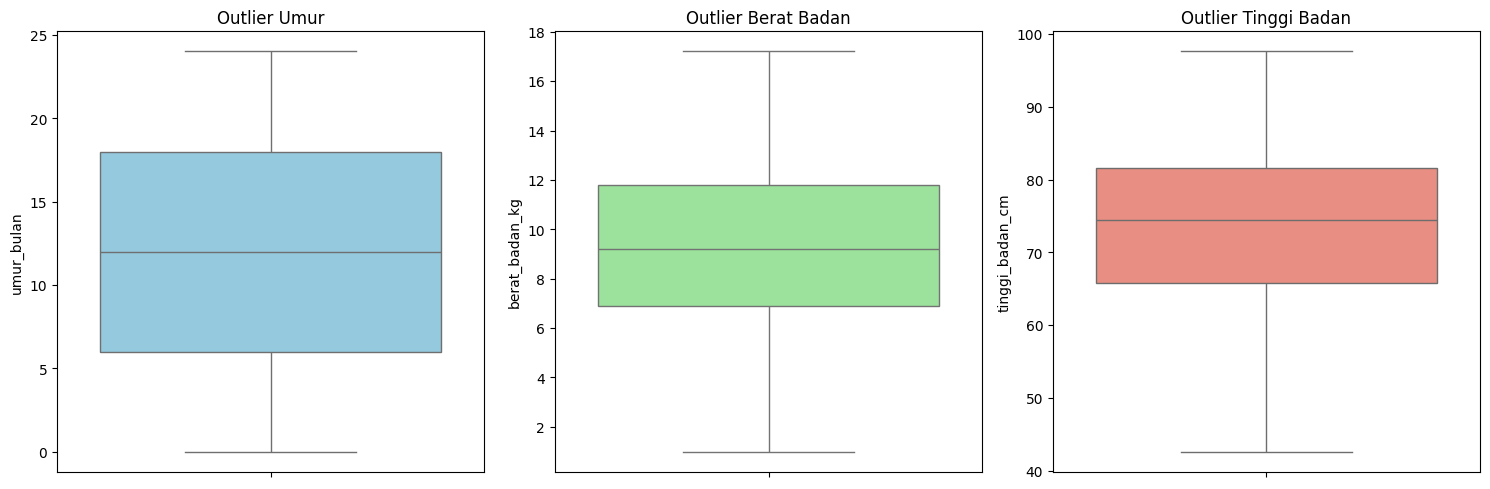

In [73]:
# Visualisasi outlier dengan boxplot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['umur_bulan'], color='skyblue')
plt.title('Outlier Umur')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['berat_badan_kg'], color='lightgreen')
plt.title('Outlier Berat Badan')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['tinggi_badan_cm'], color='salmon')
plt.title('Outlier Tinggi Badan')

plt.tight_layout()
plt.show()

### Insight

Boxplot ini digunakan untuk mengecek kembali distribusi numerik setelah tahap cleaning dasar. Jika masih terlihat titik ekstrem, data tersebut perlu dievaluasi apakah masih realistis secara antropometri atau perlu penanganan tambahan. Pada proyek ini, filter rentang umur, tinggi, dan berat sudah diterapkan sebelum visualisasi outlier.


***

# Exploratory Data Analysis (EDA)

## 1. Distribusi Status Stunting

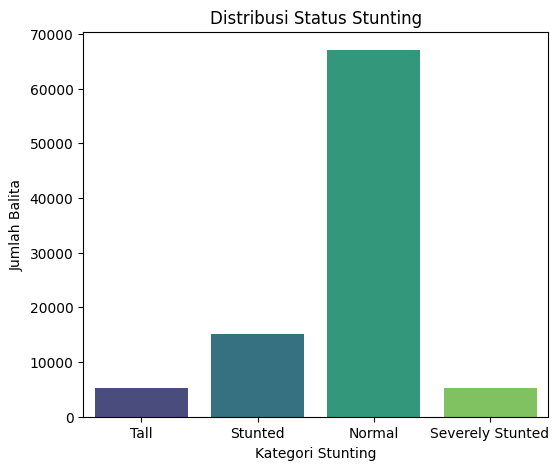

In [74]:
# Visualisasi distribusi status stunting
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x='stunting',
    palette='viridis'
)

plt.title('Distribusi Status Stunting')
plt.xlabel('Kategori Stunting')
plt.ylabel('Jumlah Balita')

plt.show()

### Insight

1. Mayoritas balita berada pada kategori `Normal`  
Distribusi data menunjukkan bahwa sebagian besar balita dalam dataset berada pada kategori `Normal`. Hal ini mengindikasikan bahwa mayoritas sampel memiliki kondisi pertumbuhan tinggi badan yang sesuai dengan standar usianya.

2. Terdapat ketidakseimbangan distribusi kelas  
Jumlah data pada kategori `Normal` jauh lebih besar dibandingkan kategori lainnya seperti `Stunted`, `Severely Stunted`, dan `Tall`. Kondisi ini menunjukkan adanya class imbalance yang perlu diperhatikan pada tahap pengembangan model machine learning agar model tidak cenderung bias terhadap kelas mayoritas.

3. Kasus stunting masih cukup signifikan  
Kategori `Stunted` dan `Severely Stunted` masih memiliki jumlah data yang cukup besar dibandingkan kategori lainnya. Hal ini menunjukkan bahwa permasalahan gangguan pertumbuhan pada balita masih cukup signifikan dalam dataset dan perlu dianalisis lebih lanjut.

4. Kategori `Tall` memiliki jumlah paling sedikit  
Balita dengan kategori `Tall` merupakan kelompok dengan jumlah paling rendah dalam dataset. Hal ini menunjukkan bahwa pertumbuhan tinggi badan di atas standar usia relatif lebih jarang ditemukan dibandingkan kategori pertumbuhan lainnya.

## 2. Distribusi Tinggi Badan berdasarkan Umur dan Status Stunting

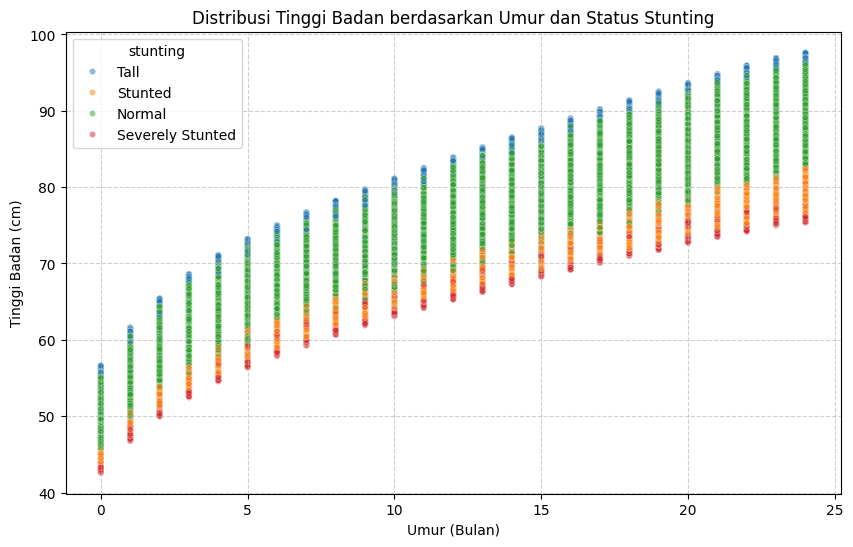

In [75]:
# Scatter plot hubungan umur dan tinggi badan berdasarkan status stunting
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='umur_bulan',
    y='tinggi_badan_cm',
    hue='stunting',
    alpha=0.5,
    s=20
)

plt.title('Distribusi Tinggi Badan berdasarkan Umur dan Status Stunting')
plt.xlabel('Umur (Bulan)')
plt.ylabel('Tinggi Badan (cm)')

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Insight

1. Pertumbuhan tinggi badan meningkat seiring bertambahnya umur  
Grafik menunjukkan pola hubungan positif antara umur dan tinggi badan, di mana tinggi badan cenderung meningkat seiring bertambahnya usia balita. Hal ini menunjukkan bahwa distribusi data memiliki pola pertumbuhan yang logis.

2. Perbedaan kategori stunting terlihat cukup jelas  
Kategori `Tall` cenderung berada pada kelompok tinggi badan paling atas, sedangkan kategori `Stunted` dan `Severely Stunted` berada pada kelompok tinggi badan yang lebih rendah dibanding kategori `Normal`. Hal ini menunjukkan adanya perbedaan pola pertumbuhan antar kategori status stunting.

3. Perbedaan tinggi badan mulai terlihat sejak usia dini  
Pada usia awal, distribusi kategori stunting sudah menunjukkan perbedaan tinggi badan antar kelompok. Hal ini mengindikasikan bahwa gangguan pertumbuhan dapat mulai terlihat sejak usia dini pada sebagian balita dalam dataset.

## 3. Analisis Faktor Jenis Kelamin

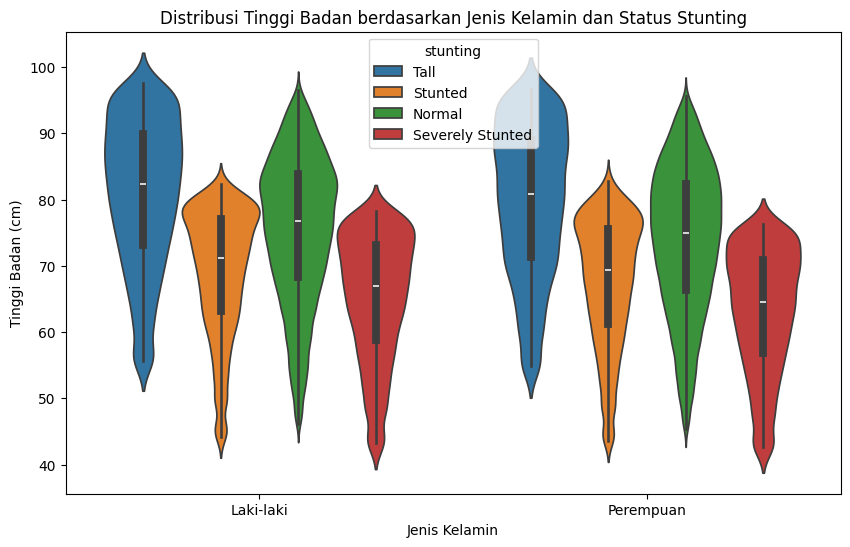

In [76]:
# Distribusi tinggi badan berdasarkan jenis kelamin dan status stunting
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='jenis_kelamin',
    y='tinggi_badan_cm',
    hue='stunting'
)

plt.title('Distribusi Tinggi Badan berdasarkan Jenis Kelamin dan Status Stunting')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Tinggi Badan (cm)')

plt.show()

### Insight

1. Distribusi tinggi badan antar jenis kelamin terlihat relatif serupa  
Bentuk distribusi pada kelompok laki-laki dan perempuan menunjukkan pola yang hampir sama pada setiap kategori stunting. Hal ini mengindikasikan bahwa tidak terdapat perbedaan distribusi tinggi badan yang terlalu signifikan berdasarkan jenis kelamin.

2. Perbedaan distribusi tinggi badan terlihat pada setiap kategori stunting  
Kategori `Tall` dan `Normal` cenderung memiliki distribusi tinggi badan pada rentang yang lebih tinggi dibandingkan kategori `Stunted` dan `Severely Stunted`. Sementara itu, kategori `Severely Stunted` memiliki distribusi tinggi badan paling rendah.

3. Terdapat overlap antar kategori stunting  
Beberapa rentang tinggi badan terlihat saling tumpang tindih antar kategori, khususnya antara `Normal` dan `Stunted`. Hal ini menunjukkan bahwa tinggi badan saja belum cukup untuk menentukan status stunting tanpa mempertimbangkan faktor umur.

4. Distribusi data menunjukkan variasi tinggi badan pada setiap kategori  
Setiap kategori memiliki rentang distribusi yang cukup luas, menunjukkan adanya variasi pertumbuhan balita dalam masing-masing kelompok status stunting.

## 4. Analisis Multivariat (Heatmap Korelasi)

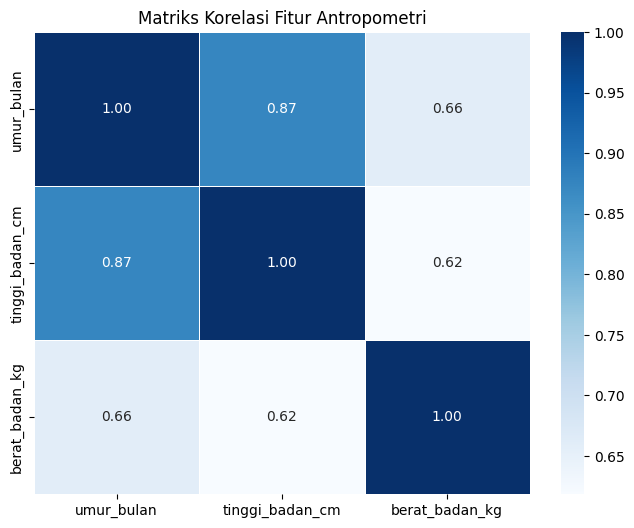

In [77]:
# Visualisasi korelasi antar fitur antropometri
plt.figure(figsize=(8, 6))

correlation = df[
    ['umur_bulan', 'tinggi_badan_cm', 'berat_badan_kg']
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriks Korelasi Fitur Antropometri')

plt.show()

### Insight

1. Umur dan tinggi badan memiliki korelasi positif yang sangat kuat  
Nilai korelasi sebesar 0.87 menunjukkan bahwa peningkatan umur balita cenderung diikuti dengan peningkatan tinggi badan. Hubungan ini merupakan korelasi paling kuat di antara fitur antropometri lainnya.

2. Umur dan berat badan memiliki korelasi positif yang cukup kuat  
Korelasi sebesar 0.66 menunjukkan bahwa berat badan cenderung meningkat seiring bertambahnya umur balita, meskipun hubungan tersebut tidak sekuat korelasi antara umur dan tinggi badan.

3. Tinggi badan dan berat badan memiliki hubungan positif  
Nilai korelasi sebesar 0.62 menunjukkan bahwa balita dengan tinggi badan yang lebih besar cenderung memiliki berat badan yang lebih tinggi. Namun, hubungan ini memiliki variasi yang lebih besar dibandingkan hubungan umur dan tinggi badan.

## Analisis Wasting vs Stunting

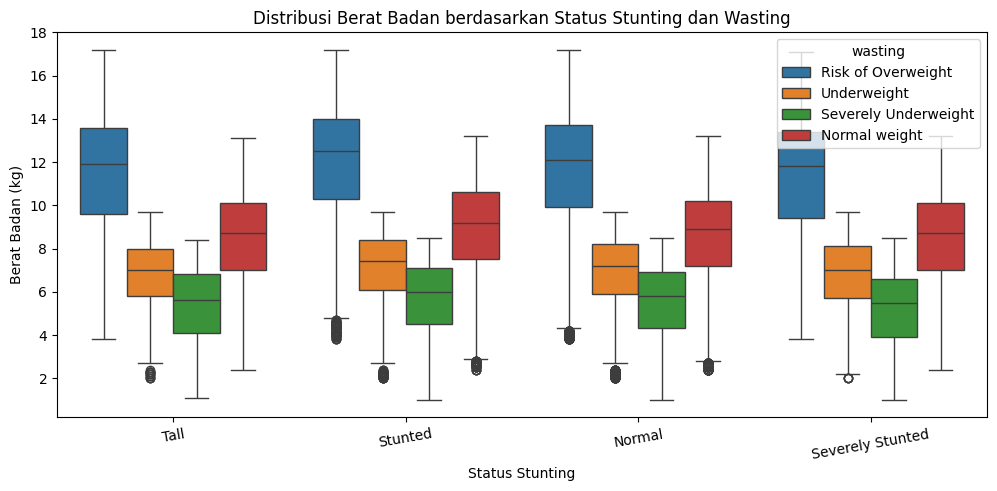

In [78]:
# Boxplot hubungan stunting, wasting, dan berat badan
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x='stunting',
    y='berat_badan_kg',
    hue='wasting'
)

plt.title('Distribusi Berat Badan berdasarkan Status Stunting dan Wasting')
plt.xlabel('Status Stunting')
plt.ylabel('Berat Badan (kg)')

plt.xticks(rotation=10)

plt.show()

### Insight

1. Status stunting dan wasting menunjukkan karakteristik yang berbeda  
Distribusi boxplot menunjukkan bahwa balita pada setiap kategori stunting dapat memiliki berbagai kategori wasting. Hal ini mengindikasikan bahwa kondisi stunting dan wasting tidak selalu terjadi secara bersamaan.

2. Distribusi berat badan konsisten pada setiap kategori wasting  
Kategori `Risk of Overweight` cenderung memiliki distribusi berat badan paling tinggi, sedangkan kategori `Severely Underweight` memiliki distribusi berat badan paling rendah pada seluruh kelompok stunting.

3. Balita dengan status stunting masih dapat memiliki berat badan normal  
Pada kategori `Severely Stunted`, masih terdapat balita dengan kategori `Normal weight` maupun `Risk of Overweight`. Hal ini menunjukkan bahwa stunting lebih berkaitan dengan gangguan pertumbuhan tinggi badan dibandingkan hanya berat badan saja.

4. Terdapat beberapa nilai ekstrem pada distribusi berat badan  
Beberapa titik outlier terlihat pada bagian bawah boxplot yang menunjukkan adanya balita dengan berat badan jauh lebih rendah dibandingkan distribusi utama kelompoknya.

---

# Explanatory Analysis

## 1. Bagaimana pola hubungan umur, tinggi badan, dan berat badan terhadap status stunting dan wasting pada balita?

### Hubungan Umur dan Tinggi Badan terhadap Status Stunting

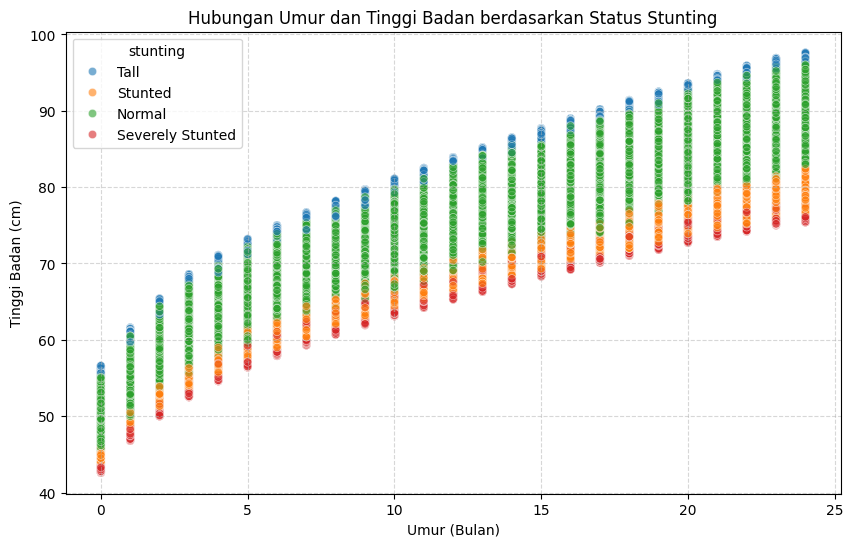

In [79]:
# Scatter plot hubungan umur dan tinggi badan berdasarkan status stunting
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='umur_bulan',
    y='tinggi_badan_cm',
    hue='stunting',
    alpha=0.6
)

plt.title('Hubungan Umur dan Tinggi Badan berdasarkan Status Stunting')
plt.xlabel('Umur (Bulan)')
plt.ylabel('Tinggi Badan (cm)')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Insight

1. Tinggi badan balita cenderung meningkat seiring bertambahnya umur  
Grafik menunjukkan pola hubungan positif antara umur dan tinggi badan, di mana tinggi badan balita meningkat secara bertahap seiring bertambahnya usia. Hal ini menunjukkan bahwa data memiliki pola pertumbuhan yang konsisten dan logis.

2. Perbedaan status stunting terlihat jelas pada setiap rentang umur  
Kategori `Tall` cenderung berada pada posisi tinggi badan paling atas, sedangkan kategori `Stunted` dan `Severely Stunted` berada pada rentang tinggi badan yang lebih rendah dibandingkan kategori `Normal`. Hal ini menunjukkan adanya perbedaan pola pertumbuhan antar status stunting.

3. Risiko stunting mulai terlihat sejak usia dini  
Pada usia awal, sudah terlihat perbedaan distribusi tinggi badan antara kategori `Normal`, `Stunted`, dan `Severely Stunted`. Hal ini mengindikasikan bahwa gangguan pertumbuhan dapat mulai teridentifikasi sejak usia dini.

4. Semakin bertambah umur, jarak pertumbuhan antar kategori semakin terlihat  
Pada rentang umur yang lebih tinggi, perbedaan tinggi badan antar kategori stunting terlihat semakin jelas. Balita dengan kategori `Stunted` dan `Severely Stunted` cenderung mengalami pertumbuhan tinggi badan yang lebih lambat dibandingkan kategori `Normal`.

### Hubungan Tinggi Badan dan Berat Badan terhadap Status Wasting

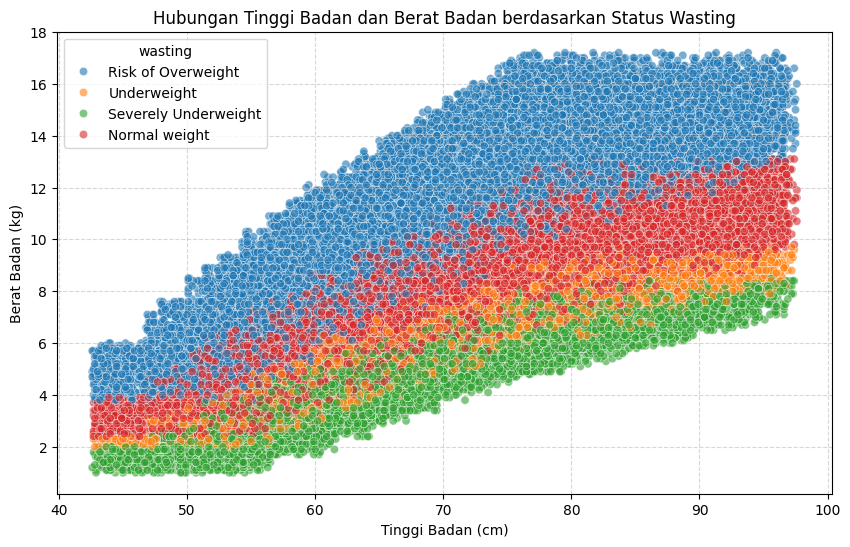

In [80]:
# Scatter plot hubungan tinggi badan dan berat badan berdasarkan status wasting
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='tinggi_badan_cm',
    y='berat_badan_kg',
    hue='wasting',
    alpha=0.6
)

plt.title('Hubungan Tinggi Badan dan Berat Badan berdasarkan Status Wasting')
plt.xlabel('Tinggi Badan (cm)')
plt.ylabel('Berat Badan (kg)')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Insight

1. Berat badan balita cenderung meningkat seiring bertambahnya tinggi badan  
Grafik menunjukkan hubungan positif antara tinggi badan dan berat badan, di mana balita dengan tinggi badan yang lebih besar cenderung memiliki berat badan yang lebih tinggi. Hal ini menunjukkan pola pertumbuhan fisik yang normal pada data.

2. Perbedaan kategori wasting terlihat jelas berdasarkan distribusi berat badan  
Kategori `Risk of Overweight` berada pada distribusi berat badan paling tinggi, sedangkan kategori `Severely Underweight` berada pada distribusi paling rendah. Sementara itu, kategori `Normal weight` dan `Underweight` berada di antara kedua kelompok tersebut.

3. Status wasting menunjukkan perbedaan proporsi berat badan terhadap tinggi badan  
Pada rentang tinggi badan yang sama, balita dapat memiliki kategori wasting yang berbeda-beda. Hal ini menunjukkan bahwa status wasting dipengaruhi oleh proporsi berat badan terhadap tinggi badan, bukan hanya tinggi badan saja.

4. Variasi berat badan semakin besar pada tinggi badan yang lebih tinggi  
Pada rentang tinggi badan yang lebih besar, distribusi berat badan terlihat semakin menyebar. Hal ini menunjukkan adanya variasi kondisi gizi yang lebih beragam pada balita dengan tinggi badan yang lebih tinggi.

## 2. Apakah distribusi tinggi dan berat badan balita stunting berbeda signifikan dibandingkan balita non-stunting?

In [81]:
# Mengelompokkan status stunting menjadi biner
df['stunting_status'] = df['stunting'].replace({
    'Tall': 'Non-Stunting',
    'Normal': 'Non-Stunting',
    'Stunted': 'Stunting',
    'Severely Stunted': 'Stunting'
})

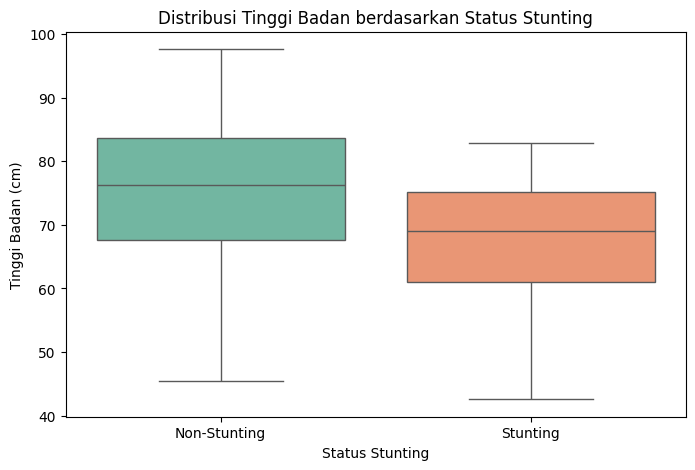

In [82]:
# Boxplot distribusi tinggi badan berdasarkan status stunting
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='stunting_status',
    y='tinggi_badan_cm',
    palette='Set2'
)

plt.title('Distribusi Tinggi Badan berdasarkan Status Stunting')
plt.xlabel('Status Stunting')
plt.ylabel('Tinggi Badan (cm)')

plt.show()

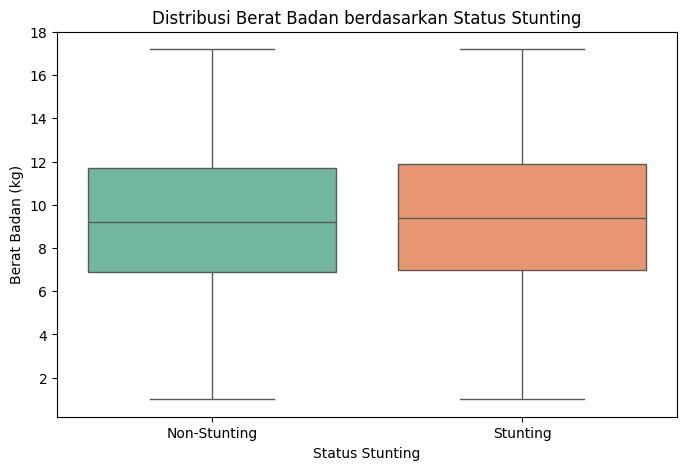

In [83]:
# Boxplot distribusi berat badan berdasarkan status stunting
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='stunting_status',
    y='berat_badan_kg',
    palette='Set2'
)

plt.title('Distribusi Berat Badan berdasarkan Status Stunting')
plt.xlabel('Status Stunting')
plt.ylabel('Berat Badan (kg)')

plt.show()

### Insight

1. Distribusi tinggi badan balita stunting cenderung lebih rendah  
Pada boxplot tinggi badan terlihat bahwa kelompok `Stunting` memiliki median tinggi badan yang lebih rendah dibandingkan kelompok `Non-Stunting`. Selain itu, distribusi tinggi badan pada kelompok stunting juga lebih terkonsentrasi pada rentang tinggi yang lebih rendah.

2. Perbedaan tinggi badan antar kelompok terlihat cukup signifikan  
Rentang distribusi tinggi badan antara kelompok `Stunting` dan `Non-Stunting` menunjukkan perbedaan yang cukup jelas. Kelompok `Non-Stunting` cenderung memiliki tinggi badan yang lebih tinggi pada sebagian besar distribusi data.

3. Distribusi berat badan antara kelompok stunting dan non-stunting terlihat lebih mirip  
Pada boxplot berat badan, distribusi kedua kelompok terlihat cukup mirip dengan median yang tidak berbeda terlalu jauh. Hal ini menunjukkan bahwa status stunting tidak selalu diikuti dengan perbedaan berat badan yang sangat besar.

4. Tinggi badan lebih merepresentasikan status stunting dibandingkan berat badan  
Perbedaan distribusi tinggi badan terlihat lebih jelas dibandingkan distribusi berat badan. Hal ini sesuai dengan definisi stunting yang lebih berfokus pada kondisi tinggi badan terhadap umur dibandingkan berat badan.

## 3. Pada rentang usia berapa perbedaan kondisi fisik antara balita stunting dan non-stunting mulai terlihat jelas?

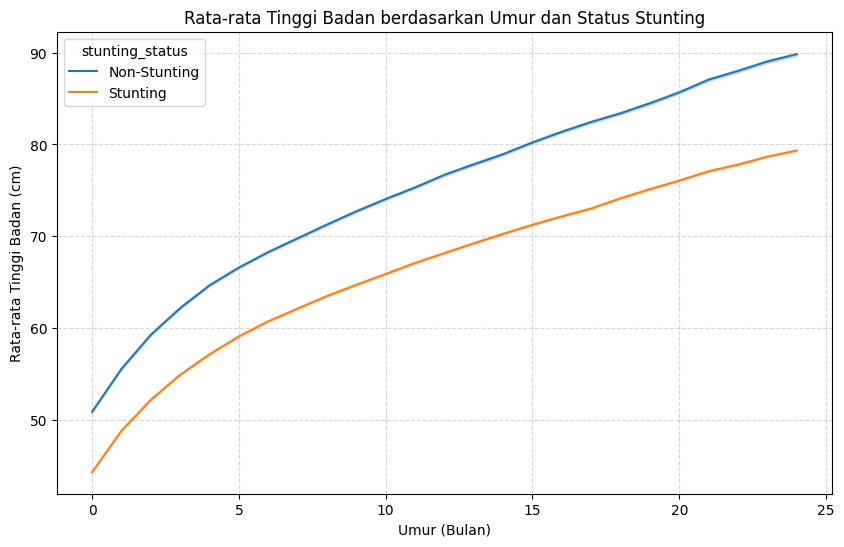

In [84]:
# Line plot rata-rata tinggi badan berdasarkan umur dan status stunting
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x='umur_bulan',
    y='tinggi_badan_cm',
    hue='stunting_status',
    estimator='mean'
)

plt.title('Rata-rata Tinggi Badan berdasarkan Umur dan Status Stunting')
plt.xlabel('Umur (Bulan)')
plt.ylabel('Rata-rata Tinggi Badan (cm)')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Insight

1. Perbedaan tinggi badan antara balita stunting dan non-stunting sudah terlihat sejak usia dini  
Pada usia awal, rata-rata tinggi badan balita dengan status `Stunting` sudah berada di bawah kelompok `Non-Stunting`. Hal ini menunjukkan bahwa perbedaan kondisi pertumbuhan dapat mulai teridentifikasi sejak usia dini.

2. Jarak pertumbuhan semakin meningkat seiring bertambahnya umur  
Seiring bertambahnya usia, jarak antara rata-rata tinggi badan kelompok `Stunting` dan `Non-Stunting` terlihat semakin besar. Hal ini menunjukkan bahwa pertumbuhan tinggi badan pada kelompok stunting cenderung lebih lambat dibandingkan kelompok non-stunting.

3. Kelompok non-stunting memiliki pola pertumbuhan yang lebih optimal  
Kelompok `Non-Stunting` menunjukkan peningkatan tinggi badan yang lebih konsisten dan lebih tinggi pada setiap rentang usia dibandingkan kelompok `Stunting`.

4. Rentang usia di atas 12 bulan mulai menunjukkan perbedaan yang lebih jelas  
Pada rentang usia sekitar 12 bulan ke atas, perbedaan rata-rata tinggi badan antara kedua kelompok terlihat semakin signifikan. Hal ini menunjukkan bahwa dampak gangguan pertumbuhan menjadi lebih terlihat pada usia balita yang lebih besar.

---

# Feature Engineering

Bagian ini dibuat lebih sesuai untuk konteks antropometri balita.

Perubahan utama:
- Tidak lagi memakai `tinggi / umur` dan `berat / umur` karena umur 0 bulan valid dan pembagian langsung terhadap umur membuat fitur tidak stabil.
- `tinggi_badan_m` hanya dipakai untuk menghitung BMI, lalu tidak dimasukkan sebagai fitur model agar tidak redundan dengan `tinggi_badan_cm`.
- Target diubah memakai mapping eksplisit, bukan `LabelEncoder`, supaya urutan kelas jelas dan mudah dijelaskan.
- Data dibagi dengan stratifikasi kombinasi `stunting` dan `wasting` agar proporsi kelas train-test lebih terjaga.
- Catatan domain: untuk aplikasi nyata, fitur terbaik sebaiknya memakai WHO z-score seperti HAZ dan WHZ. Fitur di bawah ini adalah baseline ML yang lebih aman, bukan pengganti standar klinis.


In [85]:
# Membuat salinan dataset hasil cleaning

df_feat = df.copy()

df_feat.head()

,jenis_kelamin,umur_bulan,tinggi_badan_cm,berat_badan_kg,stunting,wasting,stunting_status
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight,Non-Stunting
1,Laki-laki,20,77.7,8.5,Stunted,Underweight,Stunting
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight,Non-Stunting
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight,Stunting
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight,Stunting


## 1. Encoding Fitur Kategorikal

In [86]:
# Mengubah jenis kelamin menjadi biner
# 1 = Laki-laki, 0 = Perempuan

df_feat['jenis_kelamin'] = df_feat['jenis_kelamin'].map({
    'Laki-laki': 1,
    'Perempuan': 0
})

## 2. Feature Engineering Antropometri

In [87]:
# BMI tetap boleh dipakai sebagai fitur tambahan,
# tetapi untuk balita interpretasi yang lebih tepat adalah BMI-for-age z-score.

tinggi_badan_m = df_feat['tinggi_badan_cm'] / 100

df_feat['bmi'] = (
    df_feat['berat_badan_kg'] /
    (tinggi_badan_m ** 2)
)

# Fitur proporsi berat terhadap tinggi relevan untuk pola wasting.
df_feat['rasio_berat_tinggi'] = (
    df_feat['berat_badan_kg'] /
    df_feat['tinggi_badan_cm']
)

# Interaksi tinggi dan berat membantu model menangkap kombinasi ukuran tubuh.
df_feat['interaksi_tb_bb'] = (
    df_feat['tinggi_badan_cm'] *
    df_feat['berat_badan_kg']
)

## 3. Kelompok Umur

Kelompok umur lebih stabil dibanding rasio `tinggi / umur` atau `berat / umur`, terutama karena data memiliki anak usia 0 bulan.

In [88]:
# Kelompok umur dibuat sebagai fitur ordinal sederhana.
# Batas ini dapat disesuaikan dengan kebutuhan analisis.

df_feat['kelompok_umur'] = pd.cut(
    df_feat['umur_bulan'],
    bins=[-1, 5, 11, 23, 60],
    labels=[0, 1, 2, 3]
).astype(int)

## 4. Validasi Nilai Numerik

In [89]:
# Mengganti infinity menjadi NaN jika muncul dari proses perhitungan.
df_feat.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# Menghapus baris yang masih memiliki nilai kosong.
df_feat.dropna(inplace=True)

# Biological sanity check dibuat lebih hati-hati.
# Jangan terlalu agresif membuang data ekstrem karena kasus ekstrem bisa penting
# untuk deteksi risiko gizi. Batas ini hanya untuk nilai yang sangat tidak realistis.
df_feat = df_feat[
    (df_feat['umur_bulan'].between(0, 60)) &
    (df_feat['tinggi_badan_cm'].between(40, 120)) &
    (df_feat['berat_badan_kg'].between(1, 30)) &
    (df_feat['bmi'].between(7, 40))
].copy()

df_feat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91998 entries, 0 to 99997
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   jenis_kelamin       91998 non-null  int64  
 1   umur_bulan          91998 non-null  int64  
 2   tinggi_badan_cm     91998 non-null  float64
 3   berat_badan_kg      91998 non-null  float64
 4   stunting            91998 non-null  object 
 5   wasting             91998 non-null  object 
 6   stunting_status     91998 non-null  object 
 7   bmi                 91998 non-null  float64
 8   rasio_berat_tinggi  91998 non-null  float64
 9   interaksi_tb_bb     91998 non-null  float64
 10  kelompok_umur       91998 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 8.4+ MB


## 5. Encoding Target dengan Mapping Eksplisit

In [90]:
# Mapping eksplisit lebih mudah dijelaskan dibanding LabelEncoder,
# karena LabelEncoder mengurutkan kelas secara alfabetis.

stunting_map = {
    'Normal': 0,
    'Stunted': 1,
    'Severely Stunted': 2,
    'Tall': 3
}

wasting_map = {
    'Normal weight': 0,
    'Underweight': 1,
    'Severely Underweight': 2,
    'Risk of Overweight': 3
}

df_feat['stunting_target'] = df_feat['stunting'].map(stunting_map)
df_feat['wasting_target'] = df_feat['wasting'].map(wasting_map)

# Simpan kombinasi label untuk stratifikasi train-test.
df_feat['stratify_label'] = (
    df_feat['stunting'].astype(str) + ' | ' +
    df_feat['wasting'].astype(str)
)

df_feat[['stunting', 'stunting_target', 'wasting', 'wasting_target']].head()

,stunting,stunting_target,wasting,wasting_target
0,Tall,3,Risk of Overweight,3
1,Stunted,1,Underweight,1
2,Normal,0,Risk of Overweight,3
3,Severely Stunted,2,Risk of Overweight,3
4,Severely Stunted,2,Risk of Overweight,3


## 6. Split Fitur dan Target

In [91]:
fitur_model = [
    'jenis_kelamin',
    'umur_bulan',
    'kelompok_umur',
    'tinggi_badan_cm',
    'berat_badan_kg',
    'rasio_berat_tinggi',
    'bmi',
    'interaksi_tb_bb'
]

X = df_feat[fitur_model]

y = df_feat[
    [
        'stunting_target',
        'wasting_target'
    ]
]

print(X.shape)
print(y.shape)

(91998, 8)
(91998, 2)


## 7. Train-Test Split dengan Stratifikasi

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_feat['stratify_label']
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(73598, 8)
(18400, 8)
(73598, 2)
(18400, 2)


## 8. Scaling Numerik

In [93]:
fitur_numerik = [
    'umur_bulan',
    'tinggi_badan_cm',
    'berat_badan_kg',
    'rasio_berat_tinggi',
    'bmi',
    'interaksi_tb_bb'
]

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[fitur_numerik] = scaler.fit_transform(
    X_train[fitur_numerik]
)

X_test[fitur_numerik] = scaler.transform(
    X_test[fitur_numerik]
)

X_train.head()

,jenis_kelamin,umur_bulan,kelompok_umur,tinggi_badan_cm,berat_badan_kg,rasio_berat_tinggi,bmi,interaksi_tb_bb
8035,1,-1.015183,0,-1.237359,-1.321895,-1.111047,-0.587833,-1.330951
79258,1,0.528884,2,0.276127,-0.547782,-0.733588,-0.851690,-0.421035
60854,0,0.388514,2,-0.010450,0.814656,1.025691,0.960922,0.557527
49539,1,1.371103,2,0.267172,0.969478,1.023254,0.783136,0.804757
29658,1,0.949993,2,0.634349,0.195366,-0.053298,-0.377064,0.312428


## Catatan untuk Pengembangan Aplikasi

Untuk aplikasi deteksi risiko stunting dan wasting, baseline di atas sebaiknya dikembangkan lagi dengan fitur standar WHO:

- `HAZ` atau height-for-age z-score untuk stunting.
- `WHZ` atau weight-for-height z-score untuk wasting.
- `WAZ` atau weight-for-age z-score sebagai fitur tambahan.
- `BAZ` atau BMI-for-age z-score sebagai fitur tambahan.

Jika label target sudah dibuat dari standar WHO, maka penggunaan z-score sebagai fitur akan membuat model sangat mirip rule-based. Itu boleh saja, tetapi harus dijelaskan sebagai model yang mereplikasi standar antropometri, bukan diagnosis klinis mandiri.


In [94]:
# Menyimpan dataset hasil cleaning dasar dan feature engineering.
# df_feat masih berisi label teks, target numerik, dan kolom bantu stratifikasi.

df.to_csv('df_clean.csv', index=False)
df_feat.to_csv('df_feat.csv', index=False)

# Dokumentasi Dataset Gizi Anak (Stunting & Wasting)

Dokumen ini menjelaskan struktur data, preprocessing, dan feature engineering yang digunakan untuk baseline Machine Learning kasus **stunting** dan **wasting** pada balita.

---

# 1. Ringkasan Dataset

| Komponen | Keterangan |
|---|---|
| Sumber dataset | Kaggle - Stunting Wasting Dataset (Synthetic). |
| Versi yang digunakan | Dataset awal dari Kaggle. |
| Tujuan penggunaan | Dataset digunakan untuk analisis data antropometri dan pemodelan prediksi status stunting serta wasting. |
| `df_clean.csv` | Dataset hasil cleaning dasar sebelum feature engineering. |
| `df_feat.csv` | Dataset hasil feature engineering yang berisi fitur antropometri tambahan, target numerik, dan label stratifikasi. |

---

# 2. Tujuan Pemodelan

Model digunakan untuk memprediksi dua target secara simultan:

- **Stunting**: status pertumbuhan berdasarkan tinggi badan terhadap umur.
- **Wasting**: status gizi akut berdasarkan berat badan terhadap tinggi badan.

Pendekatan ini termasuk **multi-output classification** karena model memprediksi `stunting_target` dan `wasting_target` sekaligus.

---

# 3. Kolom Utama

| Kolom | Deskripsi |
|---|---|
| `jenis_kelamin` | Jenis kelamin anak setelah encoding biner (`Laki-laki = 1`, `Perempuan = 0`). |
| `umur_bulan` | Usia anak dalam bulan. |
| `kelompok_umur` | Kelompok umur ordinal untuk menangkap fase pertumbuhan tanpa membagi langsung dengan umur. |
| `tinggi_badan_cm` | Tinggi badan anak dalam sentimeter. |
| `berat_badan_kg` | Berat badan anak dalam kilogram. |
| `rasio_berat_tinggi` | Rasio berat badan terhadap tinggi badan, relevan untuk pola wasting. |
| `bmi` | Body Mass Index sebagai fitur tambahan, bukan standar klinis utama untuk balita. |
| `interaksi_tb_bb` | Interaksi tinggi badan dan berat badan. |
| `stunting_target` | Target numerik untuk status stunting. |
| `wasting_target` | Target numerik untuk status wasting. |
| `stratify_label` | Kombinasi label stunting-wasting untuk menjaga proporsi kelas saat train-test split. |

---

# 4. Feature Engineering

Fitur `rasio_tinggi_umur` dan `rasio_berat_umur` tidak digunakan karena umur 0 bulan merupakan nilai valid pada data balita, sementara pembagian langsung terhadap umur dapat menghasilkan nilai tidak stabil dan membuat data bayi baru lahir terbuang.

Sebagai pengganti, notebook memakai:

- `kelompok_umur`
- `rasio_berat_tinggi`
- `bmi`
- `interaksi_tb_bb`

---

# 5. Catatan Domain

Untuk aplikasi nyata, pendekatan yang lebih sesuai adalah memakai standar WHO Child Growth Standards, terutama:

- `HAZ` atau height-for-age z-score untuk stunting.
- `WHZ` atau weight-for-height z-score untuk wasting.
- `WAZ` atau weight-for-age z-score sebagai fitur tambahan.
- `BAZ` atau BMI-for-age z-score sebagai fitur tambahan.

Baseline notebook ini lebih aman dibanding rasio sederhana, tetapi belum menggantikan perhitungan z-score WHO untuk kebutuhan klinis atau aplikasi kesehatan yang serius.


In [95]:
df_feat.head()

,jenis_kelamin,umur_bulan,tinggi_badan_cm,berat_badan_kg,stunting,wasting,stunting_status,bmi,rasio_berat_tinggi,interaksi_tb_bb,kelompok_umur,stunting_target,wasting_target,stratify_label
0,1,19,91.6,13.3,Tall,Risk of Overweight,Non-Stunting,15.851147,0.145197,1218.28,2,3,3,Tall | Risk of Overweight
1,1,20,77.7,8.5,Stunted,Underweight,Stunting,14.079165,0.109395,660.45,2,1,1,Stunted | Underweight
2,1,10,79.0,10.3,Normal,Risk of Overweight,Non-Stunting,16.503765,0.130380,813.70,1,0,3,Normal | Risk of Overweight
3,0,2,50.3,8.3,Severely Stunted,Risk of Overweight,Stunting,32.805157,0.165010,417.49,0,2,3,Severely Stunted | Risk of Overweight
4,0,5,56.4,10.9,Severely Stunted,Risk of Overweight,Stunting,34.266385,0.193262,614.76,0,2,3,Severely Stunted | Risk of Overweight
